# How to effectively use PetThermoTools

- In this notebook we'll use some simple magma decompression calculations to demonstrate the simple output structure of PetThermoTools, and show how this can be used to investigate the output variables and create some simple geochemical plots.

**Before any calculations can be run** users need to download the alphaMELTS for Python files. Please see the installation guide on ReadTheDocs.

You will need to also download this excel spreadsheet:
https://github.com/gleesonm1/PetThermoTools/blob/master/docs/Examples/Intro_Tutorial/StHelens.xlsx




In [1]:
# import core python packages that we'll use for plotting and data manipulation.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import petthermotools as ptt 

ptt.__version__

alphaMELTS for Python files successfully located.
If using the Green et al. (2025) or Weller et al. (2024) thermodynamic models please run `ptt.activate_petthermotools_env()` prior to any calculations.


'0.3.23'

If the cell above returned a message stating that you need to run `sys.path.append(...)` uncomment the two lines below and append the path to the alphamelts for Python files on your machine.

In [2]:
# import sys
# sys.path.append(r'path_to_meltsdynamic.py')

On MacOS and Linux alphaMELTS prints all calculation outputs (i.e., every single step of the minimization process) in the notebook. This can get incredibly frustrating as you end up with a very long list of outputs that you have to scroll through to get to the next code cell. To avoid this and suppress outputs from the MELTS calculations run the cell below **twice**. I am working on finding a better solution.

In [4]:
import platform
if platform.system() == "Darwin" or platform.system() == "Linux":
    import sys
    import os
    sys.stdout = open(os.devnull, 'w')
    sys.stderr = open(os.devnull, 'w')

### Step 1 - load your data

In this example we'll load some melt inclusion data from the White Pumice of Mt St Helens, collected and published by Blundy and Cashman (2005). We'll use these compositions, which have measured H2O contents but no measured (or reported) CO2 contents, to simulate magma decompression with different starting CO2 contents. This example is designed, largely, so that we can discuss the input and output structures of PetThermoTools and highlight some of the ways you can work with these outputs to make publication quality figures!

In [5]:
# Melt inclusion and groundmass glass data from Mt St Helens (Blundy and Cashman, 2005)
StHelens = pd.read_excel('StHelens.xlsx', sheet_name='1980_WhitePumice') # load in compositional data from the StHelens.xlsx spreadsheet
StHelens = StHelens.fillna(0.0) # PetThermoTools should be able to handle NaN values, but for safety I prefer to set all NaNs to zero.
StHelens.head() # lets examine the first 5 rows of this DataFrame to inspect the data structure (columns headings etc.)

,sample,Type,SiO2,TiO2,Al2O3,FeOt,MnO,MgO,CaO,Na2O,K2O,H2O,Total
0,KCHB-4Aa,A1,68.05,0.33,12.96,2.72,0.12,0.98,1.95,5.60,1.93,4.63,99.26
1,KCHB-7Ab,A1,69.01,0.37,14.07,2.19,0.02,0.36,2.25,5.54,1.85,3.19,99.09
2,KCHB-8Aa,A1,70.19,0.35,14.70,2.52,0.03,0.34,2.24,6.51,1.72,1.83,100.43
3,KCHB-I IR,A1,65.81,0.51,15.03,2.13,0.00,0.37,2.35,5.65,2.44,4.92,99.2
4,KCHB-I IB',A1,69.71,0.21,14.15,2.48,0.00,0.45,2.23,6.39,2.03,2.66,100.29


For nearly all functions PetThermoTools can use either DataFrames (multiple compositions) or Dictionaries and Pandas Series (single compositions) as the starting composition of the system. If a DataFrame is supplied as the starting composition the code will, by default perform a calculation for each composition provided. 

The most important thing to note here is that the column headers must be in the form `SiO2`, `TiO2`, `Al2O3` etc. or `SiO2_Liq`, `TiO2_Liq`, `Al2O3_Liq` etc. other column headers (e.g., `MgO (wt%)`) will not be recognised by PetThermoTools and may lead to errors in your calculations.

In this example notebook we will not run a decompression calculation for every melt inclusion composition in the Blundy and Cashman (2005) dataset. Instead we will select a single composition (one of the more H2O-rich plagioclase hosted melt inclusions) and run multiple calculations at different starting CO2 contents. To isolate that specific melt inclusion as our starting composition we can use the simple code below:

In [6]:
# select a representative composition of the Mt St Helens white pumice. Here we've chosen a more mafic (~65 wt% SiO2) water rich inclusion.
WhitePumice = StHelens.loc[23]
WhitePumice

sample    006-IOAO
Type            PI
SiO2         64.91
TiO2          0.41
Al2O3        13.31
FeOt          2.78
MnO           0.02
MgO           0.71
CaO           1.95
Na2O          5.49
K2O           1.99
H2O           6.38
Total        98.27
Name: 23, dtype: object

### Step 2 - understanding and running PetThermoTools functions

In this example we're going to use the `isothermal_decompression` function. All functions in PetThermoTools have extensive documentation outlining what variables/options are available. To view this documentation you simply have to type (in a code cell):

`help(ptt.isothermal_decompression)`

if you are using MacOS or Linux, this will not return anything because we suppressed all outputs in cell 3 above! Instead, our recommendation is for you to open a new, clean notebook and run:

`import petthermotools as ptt`

`help(ptt.isothermal_decompression)`

This will print the documentation for the `isothermal_decompression` function, helping you to work out what key-word arguments are available, what they do, and what you want to use. In the cell below we run a simple decompression calculation example with three different initial CO2 contents (in wt%), read the comments to learn about each key-word argument used here.

In [7]:
Helens_decompress = ptt.isothermal_decompression(
    Model="MELTSv1.2.0",        # The most important argument is the thermodynamic model. As this is a calculation involving CO2 we'll choose the rhyolite-MELTS v1.2.0 model.
    bulk=WhitePumice,           # The 'bulk' represents the starting composition of the model (in wt%). Here we provide a single composition to be used in all calculations.
    find_liquidus=True,         # Rather than specifying a temperature we can set 'find_liquidus' to True and start at the liquidus temperature of the system. If this were False we would have to specify a temperature through the key-word argument 'T_C'
    fO2_buffer="FMQ",           # Oxygen fugacity buffer. Users must either specify a buffer or an initial Fe redox state.
    fO2_offset=2,               # Offset (in log units) from the specified buffer
    P_start_bar=3000,           # Starting pressure for the calculation in bar.
    P_end_bar=50,               # Final pressure for the calculation in bar
    dp_bar=20,                  # Approximate pressure interval between calculations in bar
    fluid_sat=True,             # This ensures that, if the system is fluid saturated, there is no excess fluid in the system at the start of the calculation - it does not force the system to be fluid saturated by increasing the H2O or CO2 content of the melt phase.
    CO2_init=[0.01,0.05,0.1],   # Initial CO2 content for the calculations. As multiple values are given multiple calcualtions will be performed.
    Frac_fluid=False,           # As False, all fluids will remain in the system from step to step. If True, fluid phase will be removed from the system after each calculation (closed vs open system degassing)
    Frac_solid=False            # If any crystallization occurs these crystals will remain in equilibruim with the melt during further decompression. If True, solid phases will be removed from the system at each step.
)

On my Mac, that calculation takes about 5 seconds. For some computers it might take a bit longer but if it's taking more than a minute something has probably gone wrong and you should double check that you have the alphaMELTS for Python files installed correctly (try running `ptt.test_alphaMELTS()`).

Now that we have successfully run a MELTS calculation lets investigate the results. Because we ran multiple calculations the results variabel (`Helens_decompress`) is a Dictionary of Dictionaries. Use the cell below to investigate the different keys associated with the upper level dictionary:

In [8]:
Helens_decompress.keys()

dict_keys(['Run 0', 'Run 1', 'Run 2'])

You should see here that there are three values, `Run 0`, `Run 1`, and `Run 2`, these represent the keys associated with each individual decompression calculation (at the different starting CO2 contents). `Run 0` will correspond to the first value passed in the `CO2_init` key-word argument (0.01 wt%), `Run 1` corresponds to the second value etc. 

However, sometimes it can be useful to have these labels mean something. When we're only varying one parameter (CO2 in this case) we can use the `label` key-word argument. Let's run the same calculation -- and examine the output dictionary -- but this time specify `label = CO2_init`:

In [9]:
Helens_decompress = ptt.isothermal_decompression(
    Model="MELTSv1.2.0",        # The most important argument is the thermodynamic model. As this is a calculation involving CO2 we'll choose the rhyolite-MELTS v1.2.0 model.
    bulk=WhitePumice,           # The 'bulk' represents the starting composition of the model (in wt%). Here we provide a single composition to be used in all calculations.
    find_liquidus=True,         # Rather than specifying a temperature we can set 'find_liquidus' to True and start at the liquidus temperature of the system. If this were False we would have to specify a temperature through the key-word argument 'T_C'
    fO2_buffer="FMQ",           # Oxygen fugacity buffer. Users must either specify a buffer or an initial Fe redox state.
    fO2_offset=2,               # Offset (in log units) from the specified buffer
    P_start_bar=3000,           # Starting pressure for the calculation in bar.
    P_end_bar=50,               # Final pressure for the calculation in bar
    dp_bar=20,                  # Approximate pressure interval between calculations in bar
    fluid_sat=True,             # This ensures that, if the system is fluid saturated, there is no excess fluid in the system at the start of the calculation - it does not force the system to be fluid saturated by increasing the H2O or CO2 content of the melt phase.
    CO2_init=[0.01,0.05,0.1],   # Initial CO2 content for the calculations. As multiple values are given multiple calcualtions will be performed.
    Frac_fluid=False,           # As False, all fluids will remain in the system from step to step. If True, fluid phase will be removed from the system after each calculation (closed vs open system degassing)
    Frac_solid=False,           # If any crystallization occurs these crystals will remain in equilibruim with the melt during further decompression. If True, solid phases will be removed from the system at each step.
    label="CO2_init"            # Tell PetThermoTools which input variable you'd like to use to label the outputs.
)

Helens_decompress.keys()

dict_keys(['CO2 = 0.01 wt%', 'CO2 = 0.05 wt%', 'CO2 = 0.1 wt%'])

You should now see three labels: `CO2 = 0.01 wt%`, `CO2 = 0.05 wt%`, and `CO2 = 0.1 wt%`. The underlying data/models will be exactly the same, this just makes it easier to keep track of everything!

Let's now examine the Dictionary of results from one individual model:

In [10]:
Helens_decompress['CO2 = 0.01 wt%'].keys()

dict_keys(['Conditions', 'fluid1', 'fluid1_prop', 'liquid1', 'liquid1_prop', 'plagioclase1', 'plagioclase1_prop', 'spinel1', 'spinel1_prop', 'All', 'PhaseList', 'mass_g', 'volume_cm3', 'rho_kg/m3', 'Input'])

For each calculation a number of different DataFrames are returned within a Dictionary structure. As you can see above, this includes a DataFrame for the composition of each phase that saturated during the calculation, as well as a second DataFrame containing the thermodynamic properties of that phase. In addition there are DataFrames for the system Conditions, as well as the mass, volume, and density of each phase in the calculation. 

We also combine all the data present in these different DataFrames into a single DataFrame called `All` so that users can see all the data in one place and/or export the entire calculation into an excel spreadsheet (see associated example notebook for how to do this). 

Finally, we provide Dictionary items (in the form of a Pandas Series and a Dictionary) for the list of saturated phases at each model step (`PhaseList`) and the input parameters (`Input`).

To start, let's examine the composition of the fluid phase produced during decompression for the system starting with 0.05 wt% CO2. For the fluid phase we only report the wt% concentration of H2O and CO2 as well as their molar fractions.

In [11]:
Helens_decompress['CO2 = 0.05 wt%']['fluid1'].head()

,H2O_Fl,CO2_Fl,X_H2O_mol_Fl,X_CO2_mol_Fl
0,67.135464,32.864536,0.833152,0.166848
1,67.616530,32.383470,0.836173,0.163827
2,68.104211,31.895789,0.839213,0.160787
3,68.598566,31.401434,0.842273,0.157727
4,69.099648,30.900352,0.845352,0.154648


We can also check the input parameters used for this calculation (this will also show the list of other key-word arguments that will id not explore in this example), this can help with reproducibility of your work!

In [12]:
Helens_decompress['CO2 = 0.05 wt%']['Input']

{'Model': 'MELTSv1.2.0',
 'comp': {'SiO2_Liq': 66.23537008677899,
  'TiO2_Liq': 0.4183716181725371,
  'Al2O3_Liq': 13.581771311893828,
  'FeOt_Liq': 2.836763654925983,
  'MnO_Liq': 0.020408371618172542,
  'MgO_Liq': 0.7244971924451252,
  'CaO_Liq': 1.989816232771823,
  'Na2O_Liq': 5.602098009188363,
  'K2O_Liq': 2.030632976008168,
  'H2O_Liq': 6.510270546197042,
  'Cr2O3_Liq': 0.0,
  'P2O5_Liq': 0.0,
  'CO2_Liq': 0.05,
  'Fe3Fet_Liq': 0.0},
 'Frac_solid': None,
 'Frac_fluid': None,
 'T_C': None,
 'T_path_C': None,
 'T_start_C': None,
 'T_end_C': None,
 'dt_C': None,
 'P_bar': None,
 'P_path_bar': None,
 'P_start_bar': 3000.0,
 'P_end_bar': 50.0,
 'dp_bar': 20.0,
 'isenthalpic': None,
 'isentropic': None,
 'isochoric': None,
 'find_liquidus': True,
 'fO2_buffer': 'FMQ',
 'fO2_offset': 2.0,
 'fluid_sat': True,
 'Crystallinity_limit': None,
 'Suppress': ['rutile', 'tridymite'],
 'Suppress_except': False}

### Step 3 - Plotting results

In PetThermoTools we provide many different functions for creating useful plots from your thermodynamic models. However, we can't predict every plot type that users might want to make. As a result, we'll provide a brief example here of how you can work with the PetThermoTools outputs to create publication quality plots from your model results. The example used here is a plot of fluid composition against pressure for these decompression models.

The first thing to discuss is that the output structure of PetThermoTools makes it very easy to loop through the thermodynamic model results, allowing you to set up your plotting code within a for loop rather than having to write multiple lines of code to plot the results of each model. For example, a for loop like that below can be used to access each thermodynamic model in the upper-level dictionary:

In [16]:
models = []
for model in Helens_decompress:
    models.append(model) ## append each individual model key onto the models list.
    print(model) # this will only work on Windows

models # print the list

['CO2 = 0.01 wt%', 'CO2 = 0.05 wt%', 'CO2 = 0.1 wt%']

This means that we can set up a plot, use a for loop to access each model/calculation, and use the key values for each model (i.e., `CO2 = 0.01 wt%`, `CO2 = 0.05 wt%`, or `CO2 = 0.1 wt%`) to label the results. As a default I like to use the matplotlib suplot function to create my figures, this makes it easily extendable if you decide you want to add different plots showing different variables.

Text(0, 0.5, 'Presssure (bar)')

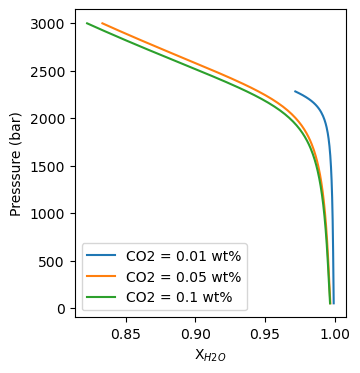

In [17]:
f, a = plt.subplots(1,1, figsize = (3.5,4))  # specify the number of columns and rows for this plot (here 1 and 1 - so only 1 plot) and the figure size in inches across and down.

## use a for loop to cycle through the main dictionary and access each model individually
for key in Helens_decompress:
    # select a single model
    res = Helens_decompress[key]

    # use a.plot to plot the results for that calculation
    # specifying label = key will label each line by the model key
    a.plot(res['All']['X_H2O_mol_Fl'],
           res['All']['P_bar'], '-', label=key)
    
# to make sure the labels show up use a.legend()
a.legend()

# set x and y labels
a.set_xlabel("X$_{H2O}$")
a.set_ylabel("Presssure (bar)")